# Customer Delinquency Risk - EDA Project
Tata iQ Forage Simulation - Data Analytics & GenAI

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)


In [3]:
df = pd.read_excel("Delinquency_prediction_dataset.xlsx")

df.head()


,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [4]:
print("Shape :", df.shape)
df.info()


Shape : (500, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month

## Checking data quality

In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100, 2)
})

missing[missing["Missing Values"] > 0]


,Missing Values,Percentage
Income,39,7.8
Credit_Score,2,0.4
Loan_Balance,29,5.8


In [6]:
df.duplicated().sum()


np.int64(0)

Before filling the missing values, I wanted to check something - what if the customers who
are missing Income/Loan_Balance/Credit_Score are actually more likely to be delinquent? If that's
true then the "missing" itself is telling us something, not just a gap to fill. So I made a flag
column for each one first.

In [7]:
df["Income_missing"] = df["Income"].isnull().astype(int)
df["Loan_Balance_missing"] = df["Loan_Balance"].isnull().astype(int)
df["Credit_Score_missing"] = df["Credit_Score"].isnull().astype(int)

# check delinquency rate for missing vs not missing
print(df.groupby("Income_missing")["Delinquent_Account"].mean() * 100)
print(df.groupby("Loan_Balance_missing")["Delinquent_Account"].mean() * 100)
print(df.groupby("Credit_Score_missing")["Delinquent_Account"].mean() * 100)



Income_missing
0    16.268980
1    12.820513
Name: Delinquent_Account, dtype: float64
Loan_Balance_missing
0    15.498938
1    24.137931
Name: Delinquent_Account, dtype: float64
Credit_Score_missing
0    16.064257
1     0.000000
Name: Delinquent_Account, dtype: float64


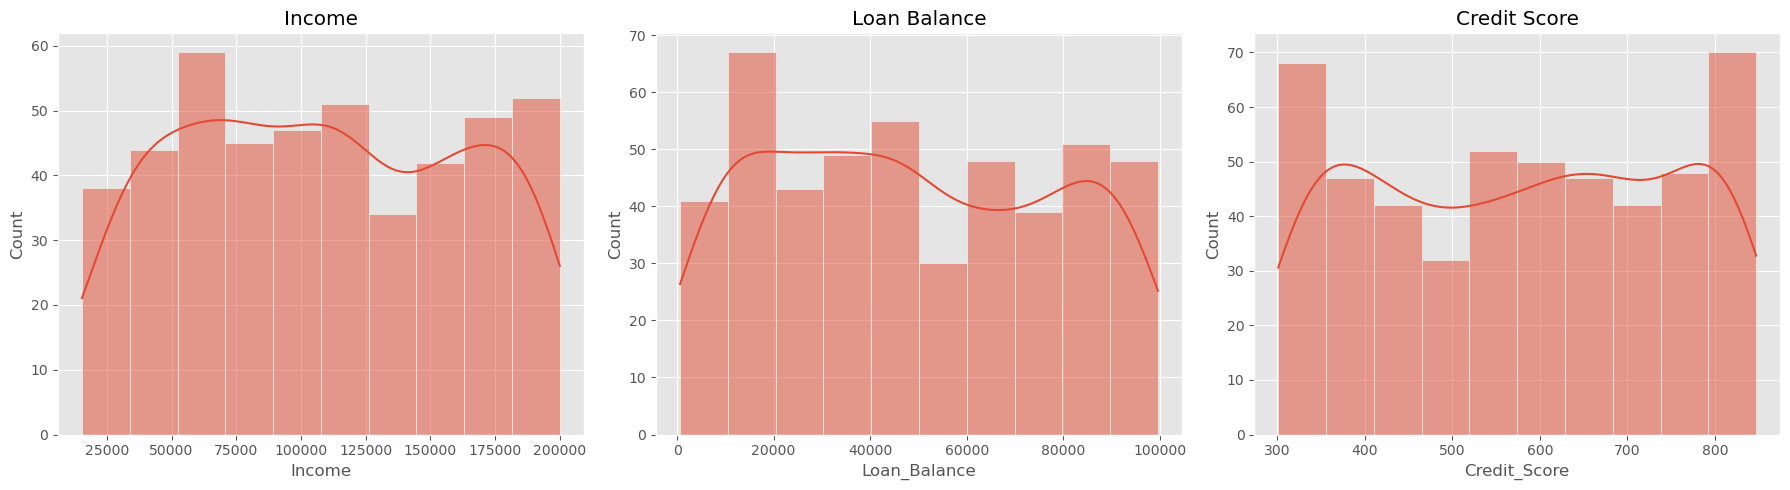

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df["Income"], kde=True, ax=axes[0])
axes[0].set_title("Income")

sns.histplot(df["Loan_Balance"], kde=True, ax=axes[1])
axes[1].set_title("Loan Balance")

sns.histplot(df["Credit_Score"], kde=True, ax=axes[2])
axes[2].set_title("Credit Score")

plt.tight_layout()
plt.show()


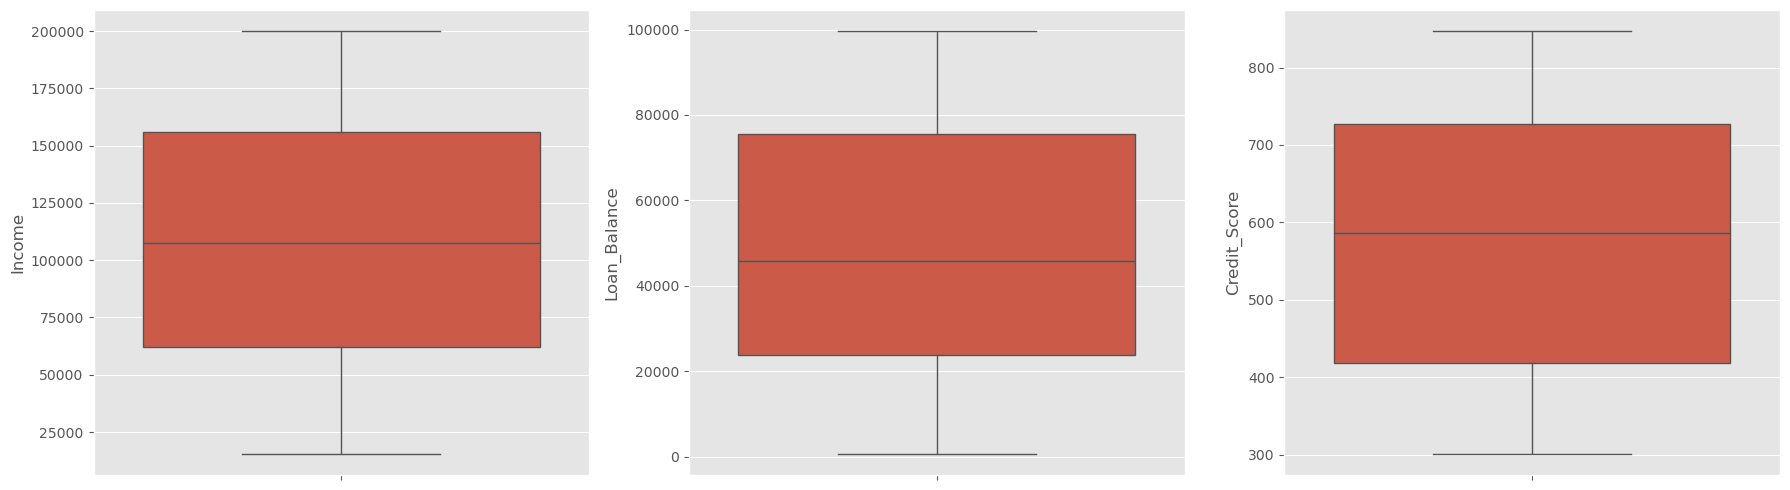

In [9]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.boxplot(y=df["Income"], ax=axes[0])
sns.boxplot(y=df["Loan_Balance"], ax=axes[1])
sns.boxplot(y=df["Credit_Score"], ax=axes[2])

plt.tight_layout()
plt.show()


In [10]:
# using median instead of mean since these have some skew/outliers (saw it in the boxplots above)
df["Income"] = df["Income"].fillna(df["Income"].median())
df["Loan_Balance"] = df["Loan_Balance"].fillna(df["Loan_Balance"].median())
df["Credit_Score"] = df["Credit_Score"].fillna(df["Credit_Score"].median())

df.isnull().sum()


Customer_ID             0
Age                     0
Income                  0
Credit_Score            0
Credit_Utilization      0
Missed_Payments         0
Delinquent_Account      0
Loan_Balance            0
Debt_to_Income_Ratio    0
Employment_Status       0
Account_Tenure          0
Credit_Card_Type        0
Location                0
Month_1                 0
Month_2                 0
Month_3                 0
Month_4                 0
Month_5                 0
Month_6                 0
Income_missing          0
Loan_Balance_missing    0
Credit_Score_missing    0
dtype: int64

### Missing values - what I did
1. Found missing values in Income, Loan_Balance and Credit_Score.
2. Made a flag column for each before filling them, just to check if missing = more risky. Didn't
   really seem to matter here.
3. Looked at histograms/boxplots - saw some skew so went with median fill instead of mean.
4. Confirmed no missing values left.

## Cleaning up categories

In [11]:
print(df["Employment_Status"].unique())


['EMP' 'Self-employed' 'Unemployed' 'employed' 'Employed' 'retired']


In [12]:
# some entries were lowercase/shortened versions of the same thing, cleaning that up
df["Employment_Status"] = df["Employment_Status"].str.title()
df["Employment_Status"] = df["Employment_Status"].replace({"Emp": "Employed"})

df["Employment_Status"].unique()


array(['Employed', 'Self-Employed', 'Unemployed', 'Retired'], dtype=object)

## EDA

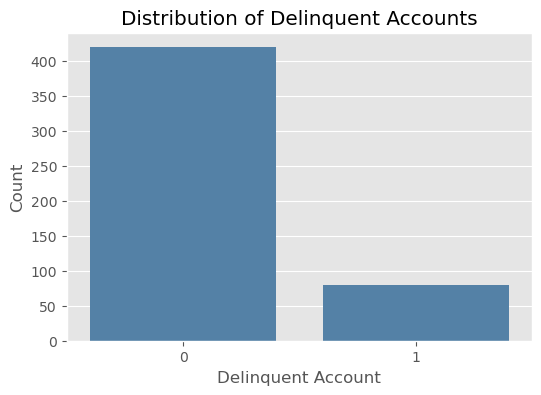

Delinquent_Account
0    84.0
1    16.0
Name: proportion, dtype: float64

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Delinquent_Account", color="steelblue")
plt.title("Distribution of Delinquent Accounts")
plt.xlabel("Delinquent Account")
plt.ylabel("Count")
plt.show()

df["Delinquent_Account"].value_counts(normalize=True)*100


The dataset is imbalanced - about 84% non-delinquent and 16% delinquent. So delinquency is
a rare event here, which means just looking at accuracy for any future model wouldn't tell us much.
Precision, Recall, F1, ROC-AUC would be better metrics to use.

In [14]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
num_cols = [c for c in num_cols if "missing" not in c]  # skip the flag columns I added above
num_cols


['Age',
 'Income',
 'Credit_Score',
 'Credit_Utilization',
 'Missed_Payments',
 'Delinquent_Account',
 'Loan_Balance',
 'Debt_to_Income_Ratio',
 'Account_Tenure']

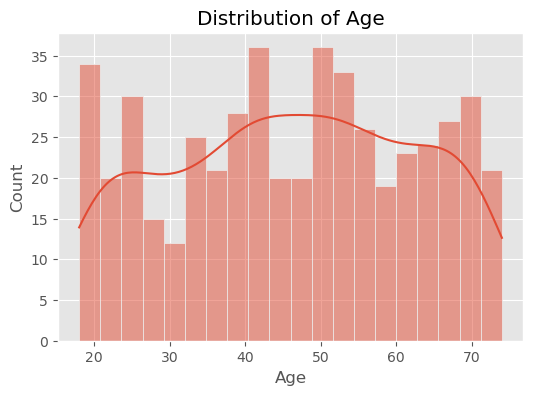

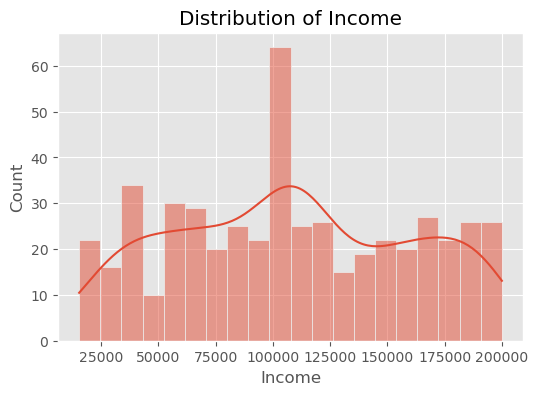

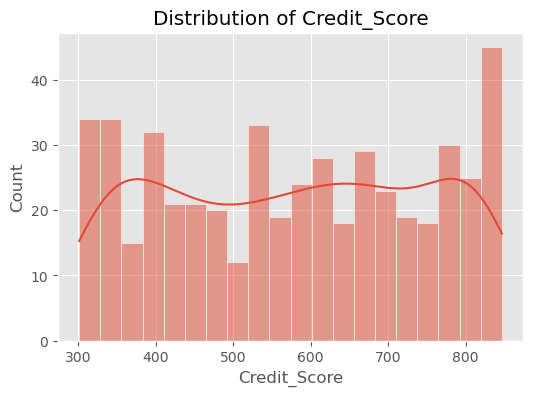

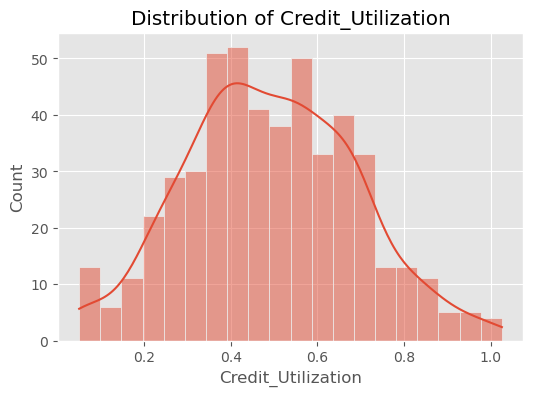

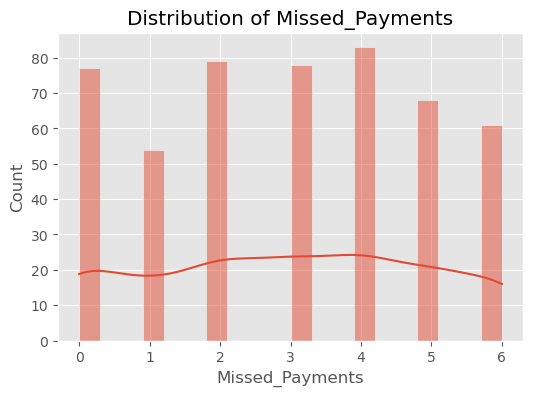

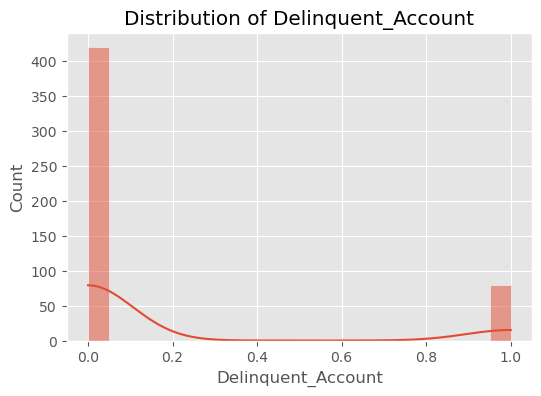

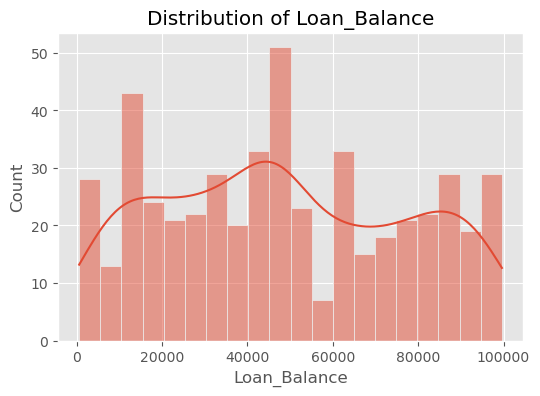

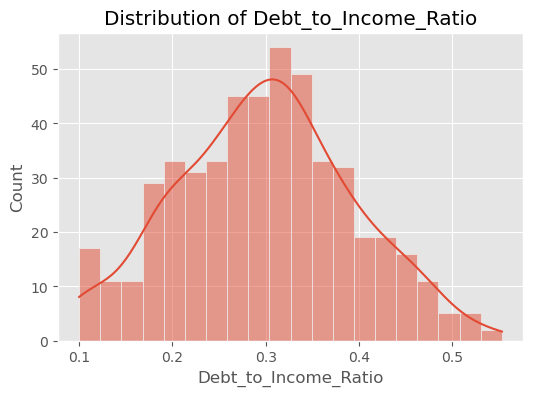

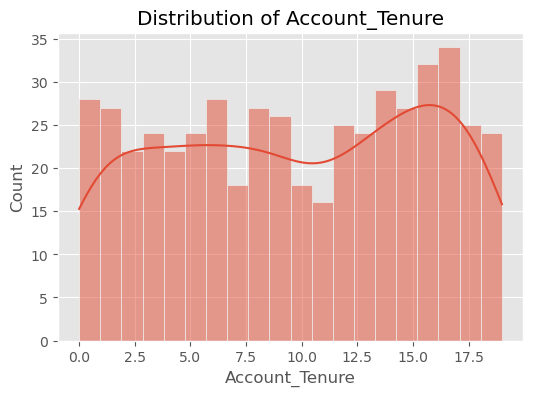

In [15]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()


### Univariate analysis - what I noticed
- Customers are aged 18-75, mostly between 35-60.
- Income goes from ~15k to ~2 lakh, so a pretty wide range.
- Credit scores are 300-850.
- Credit utilization mostly falls between 30%-60%.
- Missed payments range 0-6.
- Debt-to-income ratio and loan balance both have decent spread.
- Target is imbalanced (84% / 16%) like I found above.

In [16]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols


Index(['Customer_ID', 'Employment_Status', 'Credit_Card_Type', 'Location',
       'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6'],
      dtype='object')

## Bivariate analysis - checking against Delinquent_Account
I kept redoing the same steps (boxplot, group stats) for each column so I just wrote two small helper functions instead of copy-pasting the same code over and over. Also added a quick stats test (t-test for numbers, chi-square for categories) so I'm not just guessing from a graph whether the difference is real or not.

In [17]:
def check_numeric_column(col):
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df, x="Delinquent_Account", y=col, hue="Delinquent_Account", palette="Set2", legend=False)
    plt.title(f"{col} vs Delinquent Account")
    plt.show()

    print(df.groupby("Delinquent_Account")[col].describe())

    group0 = df[df["Delinquent_Account"] == 0][col]
    group1 = df[df["Delinquent_Account"] == 1][col]
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
    print(f"\np-value = {p_val:.4f}", "-> looks significant" if p_val < 0.05 else "-> not really significant")

    return {"feature": col, "p_value": p_val, "significant": p_val < 0.05}


def check_categorical_column(col):
    ct = pd.crosstab(df[col], df["Delinquent_Account"], normalize="index") * 100
    ct.plot(kind="bar", figsize=(8,5), colormap="Set2")
    plt.title(f"{col} vs Delinquency")
    plt.ylabel("Percentage")
    plt.xticks(rotation=0)
    plt.show()

    print(ct.round(2))

    counts = pd.crosstab(df[col], df["Delinquent_Account"])
    chi2, p_val, dof, expected = stats.chi2_contingency(counts)
    print(f"\np-value = {p_val:.4f}", "-> looks significant" if p_val < 0.05 else "-> not really significant")

    return {"feature": col, "p_value": p_val, "significant": p_val < 0.05}


results = []  # storing all the test results here to look at together later


**Does a low Credit Score mean more delinquency?**

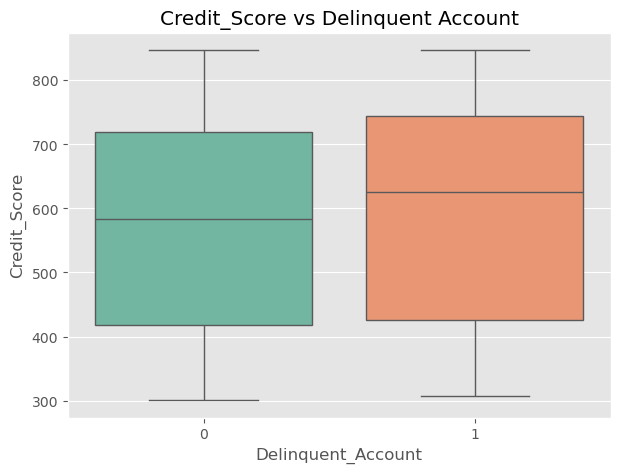

                    count        mean         std    min    25%    50%  \
Delinquent_Account                                                       
0                   420.0  575.197619  167.767729  301.0  417.5  584.0   
1                    80.0  591.150000  173.012263  307.0  426.0  625.0   

                       75%    max  
Delinquent_Account                 
0                   719.75  847.0  
1                   743.75  847.0  

p-value = 0.4492 -> not really significant


In [18]:
results.append(check_numeric_column("Credit_Score"))


**Does Credit Utilization matter?**

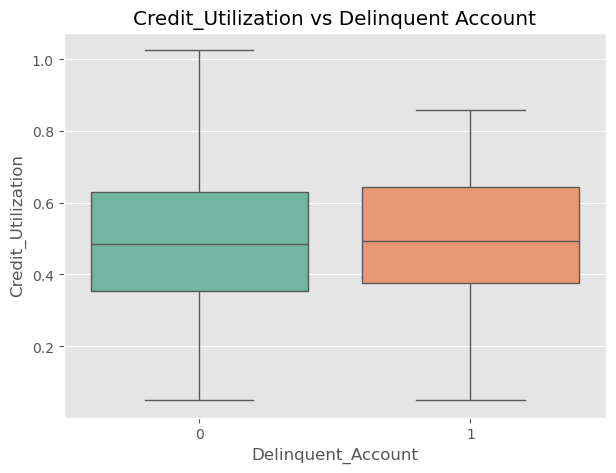

                    count      mean       std   min       25%       50%  \
Delinquent_Account                                                        
0                   420.0  0.488505  0.201595  0.05  0.354048  0.483751   
1                    80.0  0.506887  0.171911  0.05  0.376109  0.493021   

                         75%       max  
Delinquent_Account                      
0                   0.631116  1.025843  
1                   0.643264  0.858431  

p-value = 0.3962 -> not really significant


In [19]:
results.append(check_numeric_column("Credit_Utilization"))


**Does Income affect it?**

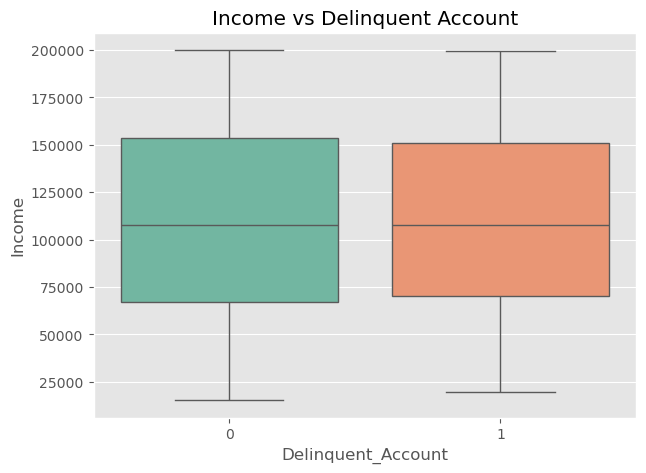

                    count           mean           std      min       25%  \
Delinquent_Account                                                          
0                   420.0  107335.361905  51568.297845  15404.0  66991.00   
1                    80.0  113511.762500  51295.792341  19835.0  70430.25   

                         50%       75%       max  
Delinquent_Account                                
0                   107658.0  153311.0  199943.0  
1                   107658.0  150754.0  199402.0  

p-value = 0.3262 -> not really significant


In [20]:
results.append(check_numeric_column("Income"))


**What about Missed Payments? (this one I forgot to check earlier, adding it now)**

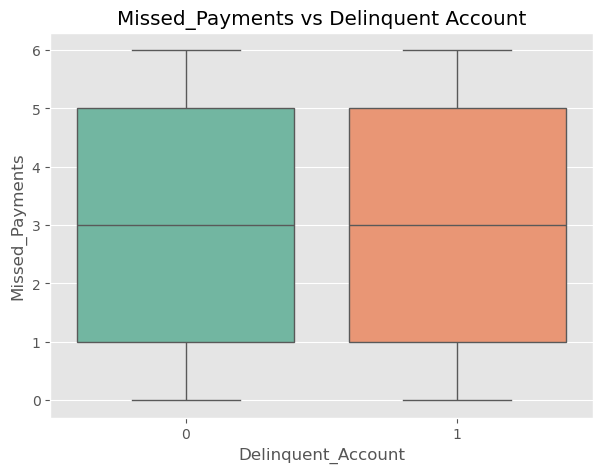

                    count      mean       std  min  25%  50%  75%  max
Delinquent_Account                                                    
0                   420.0  2.990476  1.940623  0.0  1.0  3.0  5.0  6.0
1                    80.0  2.850000  1.987938  0.0  1.0  3.0  5.0  6.0

p-value = 0.5621 -> not really significant


In [21]:
results.append(check_numeric_column("Missed_Payments"))


**Does Debt-to-Income Ratio matter?**

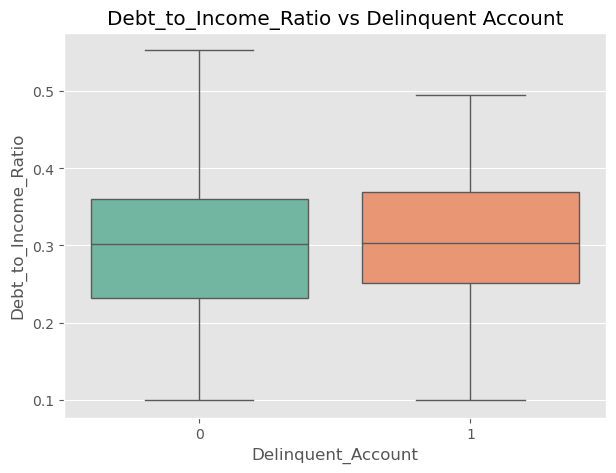

                    count      mean       std  min       25%       50%  \
Delinquent_Account                                                       
0                   420.0  0.297445  0.095414  0.1  0.232446  0.301634   
1                    80.0  0.306301  0.089896  0.1  0.251364  0.303280   

                         75%       max  
Delinquent_Account                      
0                   0.360726  0.552956  
1                   0.369609  0.494267  

p-value = 0.4256 -> not really significant


In [22]:
results.append(check_numeric_column("Debt_to_Income_Ratio"))


**Does how long they've had the account (Account_Tenure) matter?**

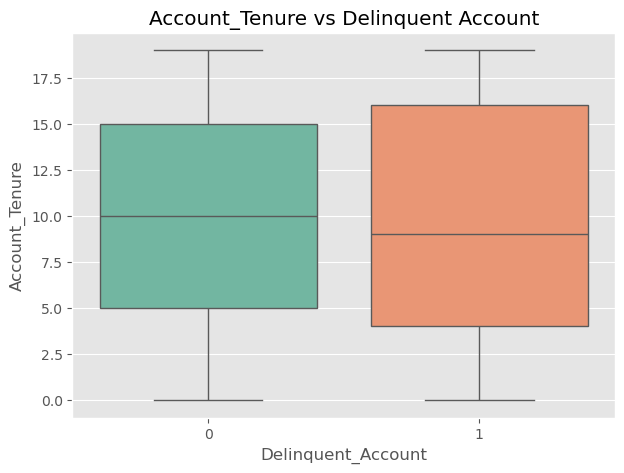

                    count      mean       std  min  25%   50%   75%   max
Delinquent_Account                                                       
0                   420.0  9.842857  5.850898  0.0  5.0  10.0  15.0  19.0
1                    80.0  9.200000  6.299287  0.0  4.0   9.0  16.0  19.0

p-value = 0.3995 -> not really significant


In [23]:
results.append(check_numeric_column("Account_Tenure"))


**Which employment status has more delinquency?**

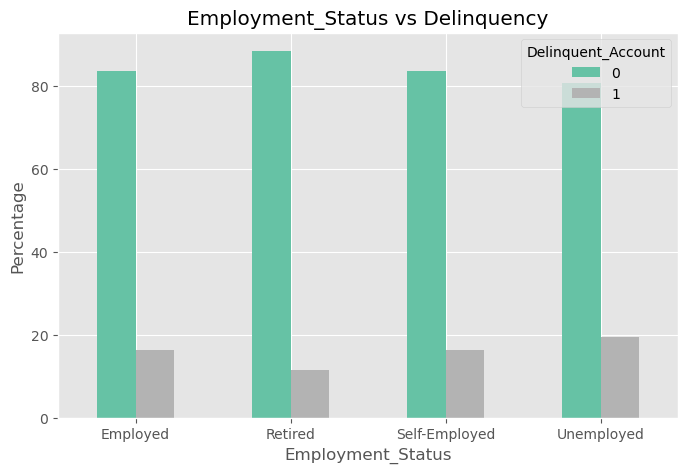

Delinquent_Account      0      1
Employment_Status               
Employed            83.75  16.25
Retired             88.51  11.49
Self-Employed       83.75  16.25
Unemployed          80.65  19.35

p-value = 0.5503 -> not really significant


In [24]:
results.append(check_categorical_column("Employment_Status"))


**Does last month's payment status (Month_1) say anything about delinquency?**

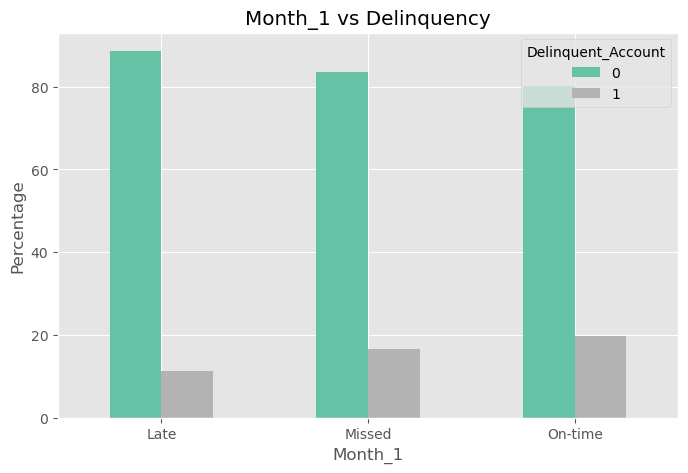

Delinquent_Account      0      1
Month_1                         
Late                88.68  11.32
Missed              83.54  16.46
On-time             80.23  19.77

p-value = 0.1058 -> not really significant


In [25]:
results.append(check_categorical_column("Month_1"))


## Using all 6 months, not just Month_1

I only looked at Month_1 before, but there's Month_1 to Month_6 in the data and I was basically
throwing away 5 months of payment history. Payment behavior over time is probably a better signal
than one single month, so let me count how many months were late/missed, and also check if things
got better or worse over the 6 months.

In [26]:
months = ["Month_1","Month_2","Month_3","Month_4","Month_5","Month_6"]

for m in months:
    print(m, df[m].unique())


Month_1 ['Late' 'Missed' 'On-time']
Month_2 ['Late' 'Missed' 'On-time']
Month_3 ['Missed' 'Late' 'On-time']
Month_4 ['Late' 'Missed' 'On-time']
Month_5 ['Missed' 'On-time' 'Late']
Month_6 ['Late' 'On-time' 'Missed']


In [27]:
bad_status = ["Late", "Missed"]

df["months_late_count"] = df[months].apply(lambda row: sum(v in bad_status for v in row), axis=1)

def get_trend(row):
    first_half = sum(v in bad_status for v in row[["Month_1","Month_2","Month_3"]])
    second_half = sum(v in bad_status for v in row[["Month_4","Month_5","Month_6"]])
    if second_half > first_half:
        return "Worsening"
    elif second_half < first_half:
        return "Improving"
    else:
        return "Stable"

df["payment_trend"] = df.apply(get_trend, axis=1)

df[["months_late_count", "payment_trend"]].head()


,months_late_count,payment_trend
0,6,Stable
1,4,Improving
2,5,Improving
3,6,Stable
4,5,Worsening


**Does months_late_count (all 6 months) predict delinquency better than just Month_1?**

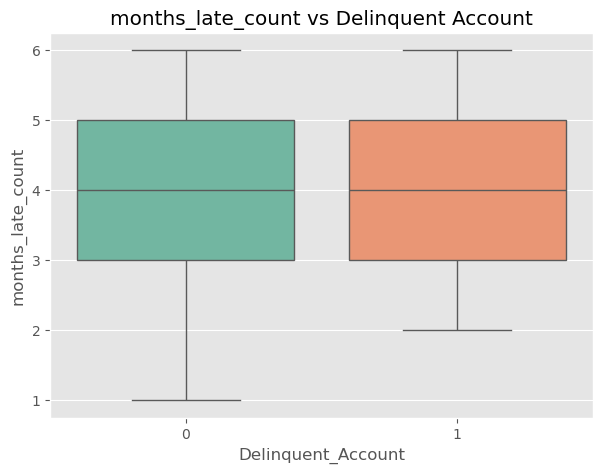

                    count      mean       std  min  25%  50%  75%  max
Delinquent_Account                                                    
0                   420.0  4.038095  1.145074  1.0  3.0  4.0  5.0  6.0
1                    80.0  3.962500  1.118812  2.0  3.0  4.0  5.0  6.0

p-value = 0.5822 -> not really significant


In [28]:
results.append(check_numeric_column("months_late_count"))


**Does the trend (getting better/worse) matter?**

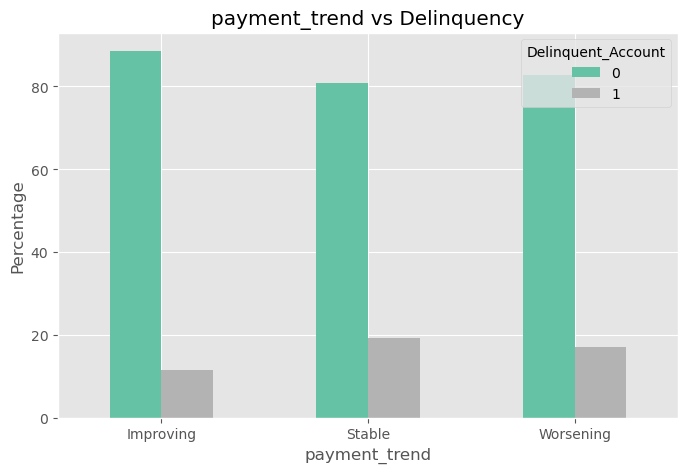

Delinquent_Account      0      1
payment_trend                   
Improving           88.61  11.39
Stable              80.84  19.16
Worsening           82.86  17.14

p-value = 0.1417 -> not really significant


In [29]:
results.append(check_categorical_column("payment_trend"))


## Correlation heatmap

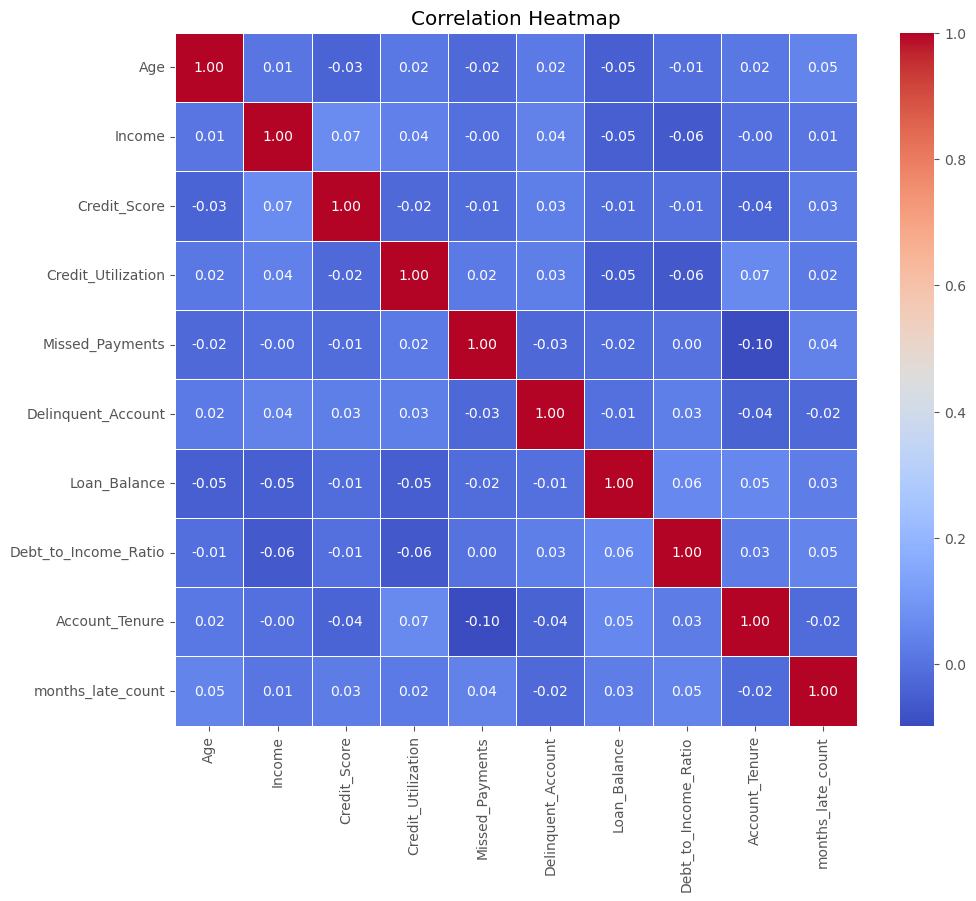

In [30]:
plt.figure(figsize=(11,9))

corr_cols = [c for c in df.select_dtypes(include=["int64","float64"]).columns if "missing" not in c]
corr = df[corr_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


## Putting all the test results together

In [31]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("p_value")
results_df


,feature,p_value,significant
7,Month_1,0.105807,False
9,payment_trend,0.141711,False
2,Income,0.326165,False
1,Credit_Utilization,0.396203,False
5,Account_Tenure,0.399491,False
4,Debt_to_Income_Ratio,0.425592,False
0,Credit_Score,0.449201,False
6,Employment_Status,0.550324,False
3,Missed_Payments,0.562120,False
8,months_late_count,0.582180,False


Honestly, none of the individual features came out statistically significant on their own here
(all p-values above 0.05). At first that seemed like a bad result, but I think it actually makes
sense - there's only 500 customers and just 80 delinquent ones, so it's a small sample. It probably
also means delinquency isn't really explained by any single variable and needs a model that looks
at combinations of features together (like the XGBoost model I built in my other project), instead
of one variable at a time.

## Using an LLM to write the reports

Instead of copy-pasting all these numbers into ChatGPT manually and pasting the answer back, I
wanted to try calling the API directly from the notebook so it pulls the real numbers from `df`
itself. I'm using Gemini here since I already used it in my RAG project.

In [32]:
# key is stored in config.py so I don't have to paste it in every time
from config import GEMINI_API_KEY
from google import genai
from IPython.display import Markdown, display

client = genai.Client(api_key=GEMINI_API_KEY)
MODEL = "gemini-2.5-flash"


In [33]:
def get_summary_text():
    # this just puts together all the numbers I want the LLM to use, as plain text
    delinquency_rate = df["Delinquent_Account"].mean() * 100

    by_class = df.groupby("Delinquent_Account")[
        ["Credit_Score", "Income", "Credit_Utilization", "Missed_Payments",
         "Debt_to_Income_Ratio", "Account_Tenure", "months_late_count"]
    ].mean().round(2)

    employment_rates = pd.crosstab(df["Employment_Status"], df["Delinquent_Account"], normalize="index")[1] * 100

    sig = results_df[results_df["significant"]]["feature"].tolist()
    not_sig = results_df[~results_df["significant"]]["feature"].tolist()

    text = f"""
    Total customers: {len(df)}
    Delinquency rate: {delinquency_rate:.1f}%

    Average feature values by delinquency status:
    {by_class.to_string()}

    Delinquency rate by employment status:
    {employment_rates.round(1).to_string()}

    Statistically significant features (p<0.05): {sig if sig else 'none'}
    Not significant: {not_sig}
    """
    return text

eda_summary = get_summary_text()
print(eda_summary)



    Total customers: 500
    Delinquency rate: 16.0%

    Average feature values by delinquency status:
                        Credit_Score     Income  Credit_Utilization  Missed_Payments  Debt_to_Income_Ratio  Account_Tenure  months_late_count
Delinquent_Account                                                                                                                       
0                         575.20  107335.36                0.49             2.99                  0.30            9.84               4.04
1                         591.15  113511.76                0.51             2.85                  0.31            9.20               3.96

    Delinquency rate by employment status:
    Employment_Status
Employed         16.2
Retired          11.5
Self-Employed    16.2
Unemployed       19.4

    Statistically significant features (p<0.05): none
    Not significant: ['Month_1', 'payment_trend', 'Income', 'Credit_Utilization', 'Account_Tenure', 'Debt_to_Income_Ratio', 'Credi

In [34]:
def ask_llm(question):
    prompt = f"""You are helping a financial services team understand customer delinquency.
Only use the numbers below, don't make anything up.

DATA:
{eda_summary}

QUESTION:
{question}
"""
    response = client.models.generate_content(model=MODEL, contents=prompt)
    display(Markdown(response.text))
    return response.text


### Executive summary

In [35]:
exec_summary = ask_llm("Write an executive summary for the financial services team - cover data quality, "
                        "the key risk drivers you can see in the numbers, and 2-3 recommendations.")


**Executive Summary: Customer Delinquency Analysis**

**1. Current State of Delinquency & Data Quality**
The financial services team is managing a customer base of 500 accounts, with an overall delinquency rate of 16.0%.

A critical finding regarding data quality and analysis limitations is that **none** of the investigated features (including Credit_Score, Income, Credit_Utilization, Missed_Payments, Debt_to_Income_Ratio, Account_Tenure, months_late_count, and Employment_Status) were found to be statistically significant (p<0.05) in differentiating delinquent from non-delinquent accounts. This indicates that, based on this analysis, the observed differences in average feature values should not be considered reliable predictors or drivers of delinquency.

**2. Key Descriptive Observations (Potential Risk Areas)**

Despite the lack of statistical significance for individual features, the following descriptive observations can be made:

*   **Employment Status:** This is the most distinct pattern observed in delinquency rates:
    *   Unemployed customers show the highest delinquency rate at 19.4%.
    *   Employed and Self-Employed customers both have a delinquency rate of 16.2%.
    *   Retired customers have the lowest delinquency rate at 11.5%.
*   **Average Feature Differences (Observed, but not Statistically Significant):**
    While not statistically significant, certain features show slight average differences between delinquent and non-delinquent accounts:
    *   Delinquent accounts (1), on average, have slightly higher Credit_Utilization (0.51 vs 0.49) and Debt_to_Income_Ratio (0.31 vs 0.30) compared to non-delinquent accounts (0).
    *   Delinquent accounts also show slightly lower average Account_Tenure (9.20 months vs 9.84 months).
    *   Counter-intuitively, delinquent accounts had slightly higher average Credit_Score (591.15 vs 575.20) and Income (113511.76 vs 107335.36), and fewer average Missed_Payments (2.85 vs 2.99) and months_late_count (3.96 vs 4.04). These counter-intuitive observations further emphasize the finding that these individual features are not statistically significant indicators of delinquency.

**3. Recommendations**

1.  **Prioritize Investigation of Unemployed Customers:** Given the highest observed delinquency rate of 19.4% among unemployed customers, initiate a focused investigation into the specific factors driving delinquency within this segment. This could involve qualitative research or exploring additional, unanalyzed data points relevant to this group.
2.  **Enhance Predictive Modeling and Feature Engineering:** As none of the current features individually proved to be statistically significant, it is recommended to explore more sophisticated analytical techniques. This could include examining interaction effects between features, building composite scores, or utilizing advanced machine learning models that can identify complex, non-linear relationships with delinquency.
3.  **Review and Expand Data Collection:** The current dataset may lack sufficiently predictive features. We recommend reviewing the existing data collection processes and considering the incorporation of new data points that might offer stronger insights into delinquency drivers. This could include more granular transaction data, behavioral patterns, or external economic indicators.

### Risk driver report

In [36]:
risk_report = ask_llm("Based on the numbers, what customer characteristics seem to matter most for "
                       "delinquency? Point out which ones are actually statistically significant vs not.")


Based on the numbers provided:

**Customer characteristics that *seem* to matter most for delinquency:**

*   **Employment Status:** There are noticeable differences in delinquency rates.
    *   Unemployed customers have the highest delinquency rate at **19.4%**.
    *   Employed and Self-Employed customers have a delinquency rate of **16.2%**.
    *   Retired customers have the lowest delinquency rate at **11.5%**.

*   **Average Feature Values by Delinquency Status:** While the differences are relatively small, here are the observations:
    *   **Credit_Score:** Non-delinquent accounts have a slightly higher average credit score (**591.15**) compared to delinquent accounts (**575.20**).
    *   **Income:** Non-delinquent accounts have a higher average income (**$113,511.76**) compared to delinquent accounts (**$107,335.36**).
    *   **Credit_Utilization:** Delinquent accounts have slightly lower average credit utilization (**0.49**) compared to non-delinquent accounts (**0.51**).
    *   **Missed_Payments:** Delinquent accounts have a slightly higher average number of missed payments (**2.99**) compared to non-delinquent accounts (**2.85**).
    *   **Debt_to_Income_Ratio:** Delinquent accounts have a slightly higher average debt-to-income ratio (**0.31**) compared to non-delinquent accounts (**0.30**).
    *   **Account_Tenure:** Non-delinquent accounts have a slightly higher average account tenure (**9.84**) compared to delinquent accounts (**9.20**).
    *   **months_late_count:** Delinquent accounts have a slightly higher average months late count (**4.04**) compared to non-delinquent accounts (**3.96**).

**Statistical Significance:**

*   **None** of the features are statistically significant (p<0.05).
*   The features explicitly listed as "Not significant" are: 'Month_1', 'payment_trend', 'Income', 'Credit_Utilization', 'Account_Tenure', 'Debt_to_Income_Ratio', 'Credit_Score', 'Employment_Status', 'Missed_Payments', 'months_late_count'.

In summary, while **Employment Status** shows the most distinct differences in delinquency rates, and other features like **Credit_Score**, **Income**, and **Missed_Payments** show some minor differences in averages, **none of these observed differences are statistically significant** according to the provided data.

### No-code risk framework

In [37]:
risk_framework = ask_llm("Suggest a Low/Medium/High risk framework for these customers using specific "
                          "thresholds based on the numbers above (like number of late months, employment "
                          "status etc). Also suggest how this could be evaluated later (precision, recall, etc).")


Based on the provided numbers, the most distinct difference in delinquency rates is observed across different `Employment_Status` categories. All other features listed (Credit_Score, Income, Credit_Utilization, Missed_Payments, Debt_to_Income_Ratio, Account_Tenure, months_late_count) are explicitly stated as **not statistically significant (p<0.05)**. Therefore, building thresholds on these non-significant features would be speculative and not truly data-driven according to the provided information.

### Low/Medium/High Risk Framework

The framework will leverage the `Delinquency rate by employment status` directly:

*   **High Risk:** Customers with **Unemployed** status.
    *   **Reasoning:** This group has the highest observed delinquency rate at **19.4%**.
*   **Medium Risk:** Customers with **Employed** or **Self-Employed** status.
    *   **Reasoning:** Both these groups have a moderate and equal delinquency rate of **16.2%**.
*   **Low Risk:** Customers with **Retired** status.
    *   **Reasoning:** This group has the lowest observed delinquency rate at **11.5%**.

**Note on other features:** While average values are provided for features like `Credit_Score`, `Income`, `Credit_Utilization`, `Missed_Payments`, `Debt_to_Income_Ratio`, `Account_Tenure`, and `months_late_count`, the data explicitly states that **none of these features are statistically significant**. Therefore, we cannot confidently define thresholds using these numbers without making unsubstantiated assumptions about their impact on delinquency.

### How this could be evaluated later

To evaluate the effectiveness of this risk framework, the following metrics and approaches can be used:

1.  **Delinquency Rate by Predicted Risk Group:**
    *   Track the actual delinquency rate for customers categorized into Low, Medium, and High risk groups by this framework.
    *   Compare these observed rates to the rates used to define the framework (11.5%, 16.2%, 19.4%). If the framework is effective, the actual delinquency rates in the predicted High-risk group should be higher than in the Medium-risk group, which in turn should be higher than in the Low-risk group.

2.  **Classification Metrics (assuming a binary outcome: delinquent vs. non-delinquent):**
    *   **Precision:** For each risk group (e.g., High Risk), what proportion of customers identified as high risk actually become delinquent?
    *   **Recall (Sensitivity):** Of all customers who actually become delinquent, what proportion were correctly identified as High or Medium risk by the framework?
    *   **F1-Score:** A balance between precision and recall, especially useful if there's an imbalance between delinquent and non-delinquent customers.
    *   **Specificity:** What proportion of customers who do not become delinquent were correctly identified as Low or Medium risk?
    *   **Accuracy:** The overall proportion of correct classifications (both delinquent and non-delinquent).

3.  **Confusion Matrix:**
    *   This table will break down the predictions into True Positives (correctly identified as delinquent), True Negatives (correctly identified as non-delinquent), False Positives (incorrectly identified as delinquent), and False Negatives (incorrectly identified as non-delinquent). This provides a detailed view of where the framework succeeds and fails.

4.  **Lift Charts / Gain Charts:**
    *   These charts can demonstrate how much better this framework performs in identifying delinquent customers compared to a random selection of customers. They would show the percentage of total delinquencies captured by targeting a certain percentage of the highest-risk customers identified by the framework.

### Collections strategy

In [38]:
collections_strategy = ask_llm("Suggest an outreach/collections strategy for each risk tier from the "
                                "framework above. Keep it fair and don't use sensitive demographic info, "
                                "mention it should stay transparent and have human oversight.")


Based on the provided data:

**Overall Context:**
*   The team is managing 500 total customers, with an overall delinquency rate of 16.0%. This means approximately 80 customers are currently delinquent (0.16 * 500).

**Key Constraint & Implication for Strategy:**
It is critical to note that **none of the individual features provided (including Credit_Score, Income, Credit_Utilization, Missed_Payments, Debt_to_Income_Ratio, Account_Tenure, months_late_count, Employment_Status, payment_trend, and Month_1) were found to be statistically significant predictors of delinquency (p<0.05).**

This means that strategies cannot be reliably designed to proactively target individuals based on these specific data points for *predictive* risk segmentation. Instead, outreach must be based on observed group delinquency rates and general best practices, with a focus on empathy and resolution.

**Risk Tiers and Outreach/Collections Strategy:**

Given the lack of statistically significant predictive features, the most actionable segmentation for collections strategy is based on the *observed delinquency rates by employment status*. This allows for tailoring the approach to groups exhibiting different levels of current delinquency.

**Tier 1: Highest Delinquency Group (Unemployed)**
*   **Observed Delinquency Rate:** 19.4%
*   **Strategy Focus:** Due to the highest observed delinquency rate, this group may be facing significant financial hardship. The strategy should be highly empathetic, focusing on understanding their current situation.
    *   **Approach:** Proactive, compassionate outreach offering flexible payment solutions, deferral programs, or hardship assistance. Prioritize early and direct communication to explore options rather than punitive measures.
    *   **Goal:** To mitigate further financial distress and work collaboratively towards a sustainable repayment plan, acknowledging the higher observed risk.

**Tier 2: Moderate Delinquency Group (Employed & Self-Employed)**
*   **Observed Delinquency Rate:** 16.2%
*   **Strategy Focus:** This group exhibits a delinquency rate similar to the overall customer base. Standard, yet supportive, collections practices are appropriate.
    *   **Approach:** Utilize a mix of automated reminders (email, SMS) and personal calls. Offer self-service options for payment arrangements or temporary adjustments. The communication should be clear, concise, and encourage prompt resolution, with options to speak to a representative for personalized support.
    *   **Goal:** To prevent escalation of delinquency through timely communication and accessible solutions.

**Tier 3: Lower Delinquency Group (Retired)**
*   **Observed Delinquency Rate:** 11.5%
*   **Strategy Focus:** With the lowest observed delinquency rate, this group may require a gentler, less frequent approach, ensuring ease of payment.
    *   **Approach:** Less frequent and softer-touch communication. Focus on ensuring clarity regarding payment due dates and accessible payment methods. Provide resources for managing finances if needed, but avoid aggressive tactics. Emphasize convenience and support.
    *   **Goal:** To maintain good customer relationships while facilitating timely payments and addressing any potential minor issues.

**Fairness, Transparency, and Human Oversight:**

*   **Fairness:** All strategies should be applied consistently within these defined tiers based solely on the employment status (a financial status) and *not* on any sensitive demographic information. The lack of statistically significant features means we must avoid making assumptions about individual risk based on specific credit or income characteristics.
*   **Transparency:** Clearly communicate the purpose of outreach, available options, and consequences of non-payment. Avoid jargon and ensure all communications are easy to understand.
*   **Human Oversight:** Despite tiered strategies, human agents should have the discretion to deviate from standard scripts and provide individualized support when a customer's specific circumstances warrant it. This ensures empathy and fairness, especially for vulnerable customers, and acts as a safeguard against any potential biases in group-based strategies. This is crucial given that the predictive power of individual features is not established by the data.

## Making it interactive

The reports above are fixed - same prompts, same output every time. I wanted to try something closer to
what I did in my RAG project, where instead of the model just answering from a static block of text, it
can actually go look something up. So here I wrote a few small functions that pull real numbers from `df`
(like looking up one specific customer, or comparing two groups), and let Gemini decide which one to call
based on the question. This way it can't just make up an answer - it has to actually call a function and
use the real result.

In [39]:
# adding : str after each parameter here - turns out the gemini library needs to know
# the type of each argument to figure out how to call these functions automatically,
# otherwise it throws a ValueError (found that out the hard way)
# also wrapping numbers in float()/int() below since pandas gives back numpy numbers,
# which caused a second error when trying to send the result back to the API

def get_customer(customer_id: str):
    row = df[df["Customer_ID"] == customer_id]
    if row.empty:
        return {"error": "customer not found"}
    row = row.iloc[0]

    features = ["Credit_Score", "Income", "Credit_Utilization", "Missed_Payments",
                "Debt_to_Income_Ratio", "Account_Tenure", "months_late_count"]
    avg = df[features].mean()

    return {
        "customer_id": str(row["Customer_ID"]),
        "is_delinquent": bool(row["Delinquent_Account"]),
        "employment_status": str(row["Employment_Status"]),
        "payment_trend": str(row["payment_trend"]),
        "compared_to_average": {f: {"this_customer": round(float(row[f]),2), "average": round(float(avg[f]),2)} for f in features},
    }


def get_delinquency_rate_by(column: str, value: str = None):
    if value:
        subset = df[df[column].astype(str).str.lower() == value.lower()]
        if subset.empty:
            return {"error": "no rows matched"}
        return {"count": int(len(subset)), "delinquency_rate": round(float(subset["Delinquent_Account"].mean())*100, 2)}
    else:
        out = df.groupby(column)["Delinquent_Account"].mean() * 100
        return {str(k): round(float(v), 2) for k, v in out.to_dict().items()}


def compare_groups(column: str, value1: str, value2: str):
    out = {}
    for v in [value1, value2]:
        subset = df[df[column].astype(str).str.lower() == v.lower()]
        out[v] = {
            "count": int(len(subset)),
            "delinquency_rate": round(float(subset["Delinquent_Account"].mean())*100, 2) if len(subset) else None,
        }
    return out


def get_trend_breakdown(column: str):
    ct = pd.crosstab(df[column], df["payment_trend"], normalize="index") * 100
    result = {}
    for idx, row in ct.round(2).iterrows():
        result[str(idx)] = {str(k): float(v) for k, v in row.to_dict().items()}
    return result


def get_test_results():
    records = results_df.sort_values("p_value").to_dict(orient="records")
    return [{"feature": str(r["feature"]), "p_value": round(float(r["p_value"]), 4), "significant": bool(r["significant"])} for r in records]


In [40]:
from google.genai import types

my_tools = [get_customer, get_delinquency_rate_by, compare_groups, get_trend_breakdown, get_test_results]

chat = client.chats.create(
    model=MODEL,
    config=types.GenerateContentConfig(
        tools=my_tools,
        system_instruction="You're helping analyze customer delinquency data. Only answer using the "
                            "functions given to you, don't guess numbers. If a customer isn't found, "
                            "just say so."
    ),
)

def ask(question):
    response = chat.send_message(question)
    display(Markdown(f"**Q: {question}**\n\n{response.text}"))


Trying it out with a few questions:

In [41]:
import time

def ask_llm(question, retries=3):
    for attempt in range(retries):
        try:
            prompt = f"""You are helping a financial services team understand customer delinquency.
Only use the numbers below, don't make anything up.

DATA:
{eda_summary}

QUESTION:
{question}
"""
            response = client.models.generate_content(model=MODEL, contents=prompt)
            display(Markdown(response.text))
            return response.text
        except Exception as e:
            if "429" in str(e) and attempt < retries - 1:
                print(f"Hit the rate limit, waiting a bit and trying again... (attempt {attempt+1})")
                time.sleep(20)
            else:
                raise

In [42]:
ask("Why is customer CUST0002 high risk?")


**Q: Why is customer CUST0002 high risk?**

Customer CUST0002 is high risk because they are currently delinquent. They have also missed 6 payments, which is higher than the average of 2.97 missed payments. Additionally, their credit score is 493, which is lower than the average credit score of 577.75.

In [43]:
ask("Which employment status has the highest delinquency rate?")


ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash\nPlease retry in 35.345237867s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'model': 'gemini-2.5-flash', 'location': 'global'

In [44]:
ask("Which group has the most customers whose payments are getting worse?")


**Q: Which group has the most customers whose payments are getting worse?**

I'm sorry, I cannot fulfill this request. The available tools do not allow me to break down payment trends by different customer groups in a way that would identify which group has the most customers whose payments are getting worse.

In [ ]:
ask("What are the strongest predictors of delinquency here, and are they actually significant?")


## Ethical AI notes
- The AI is meant to support the team's decisions, not replace them.
- Shouldn't use sensitive demographic info in the risk scoring.
- Risk scores should be explainable, not a black box.
- Customer data needs to be handled securely and follow privacy rules.
- Should probably re-check the model/framework every so often as new data comes in.

## Final thoughts

None of the individual variables were statistically significant on their own in this dataset, which
was a bit surprising at first, but with only 500 customers (80 delinquent) that's not too unusual.
It also suggests a single-variable rule-based approach probably isn't enough, and a proper model that
can combine features (like the one I built in my Loan Default project) would work better here.

The LLM part turned this from a "write a report once" thing into something that can actually be
re-run and asked follow-up questions, which felt like a more realistic way to use GenAI for this kind
of work instead of just prompting it once.